<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 01: Aritmética de Punto Flotante y Errores</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas Fuhrer y Manuel A. Sánchez | <b>Fecha:</b> 13 de Marzo, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li>Familiarizarse con el entorno <b>Python + Numpy</b>.</li>
        <li>Entender las limitaciones de la representación <b>IEEE-754</b>.</li>
        <li>Analizar el <b>Épsilon de Máquina</b>.</li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-left: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> _______________________________________</li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> _________________________</li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 1.26.4
Estilo usado: <function context at 0x741865158f70>


<div class="alert-block alert-warning "; style=" border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h2 > Numeros Binarios </h2>
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría: El Estándar IEEE-754</h3>
    <p>En el computador, los números reales se aproximan usando notación científica binaria. Un número de doble precisión (64 bits) se representa como:</p>
    <p style="text-align: center; font-size: 1.2em;">
        $$ x = (-1)^s \times (1.m) \times 2^{e - 1023} $$
    </p>
    <ul>
        <li><b>s (Signo):</b> 1 bit</li>
        <li><b>e (Exponente):</b> 11 bits</li>
        <li><b>m (Mantisa/Fracción):</b> 52 bits</li>
    </ul>
    <p>Esto implica que hay un límite en la precisión. El espacio entre el 1.0 y el siguiente número representable se llama <b>Épsilon de Máquina ($\epsilon_{mach}$)</b>.</p>
</div>


## El Épsilon de Máquina ($\epsilon_{mach}$)

El **épsilon de máquina** es una medida del error de redondeo relativo máximo en la aritmética de punto flotante. Se define típicamente como el número positivo más pequeño $\epsilon$ tal que:
$$1 + \epsilon > 1$$

En la computadora, debido a la precisión finita, si sumamos un número extremadamente pequeño a $1$, el resultado numérico seguirá siendo exactamente $1$. A continuación, calcularemos este valor de forma empírica y lo compararemos con la constante de la librería NumPy.

> [!NOTE]
> **Estándar IEEE 754:** Por defecto, Python y NumPy utilizan precisión doble (64 bits) para representar números de punto flotante.

In [3]:
import numpy as np

def compute_epsilon_machine():
    """Calcula el épsilon de máquina de forma iterativa."""
    epsilon = 1.0
    while 1.0 + epsilon > 1.0:
        epsilon = epsilon / 2.0
    # Retornamos el último valor que cumplió la condición
    return 2.0 * epsilon

eps_calculado = compute_epsilon_machine()
eps_numpy = np.finfo(float).eps

print("Cálculo del Épsilon de Máquina (Positivo):")
print("-" * 45)
print(f"* Calculado por función : {eps_calculado}")
print(f"* Provisto por NumPy    : {eps_numpy}")

Cálculo del Épsilon de Máquina (Positivo):
---------------------------------------------
* Calculado por función : 2.220446049250313e-16
* Provisto por NumPy    : 2.220446049250313e-16


### Epsilon de Máquina Negativo

Debido a cómo se distribuyen los números de punto flotante (son más densos cerca del cero y se separan más a medida que nos alejamos), la distancia entre $1$ y el siguiente flotante menor que $1$ no es igual a la distancia entre $1$ y el flotante mayor que $1$. 

Buscamos el menor $\epsilon$ tal que:
$$1 - \epsilon < 1$$

In [16]:
def compute_epsilon_machine_negative():
    """Calcula la distancia al flotante representable inmediatamente inferior a 1."""
    epsilon = -1.0
    while 1.0 + epsilon < 1.0:
        epsilon = epsilon / 2.0
    return 2.0 * abs(epsilon)

eps_neg_calculado = compute_epsilon_machine_negative()
eps_neg_numpy = np.finfo(float).epsneg

print("Cálculo del Épsilon de Máquina (Negativo):")
print("-" * 45)
print(f"* Calculado por función : {eps_neg_calculado}")
print(f"* Provisto por NumPy    : {eps_neg_numpy}")

Cálculo del Épsilon de Máquina (Negativo):
---------------------------------------------
* Calculado por función : 1.1102230246251565e-16
* Provisto por NumPy    : 1.1102230246251565e-16


### El número más grande representable ($N_{max}$):
Ocurre cuando el exponente es máximo ($2046 - 1023 = 1023$) y la mantisa está completamente llena de unos. La fracción máxima es $f = 1 - 2^{-52}$.
$$N_{max} = (-1)^0 \times 2^{1023} \times (1 + f) = 2^{1023} \times (2 - 2^{-52})$$

> [!WARNING]
> **Desbordamiento (Overflow):** Cualquier cálculo que supere este límite máximo resultará en `inf` (infinito), lo que puede arruinar la convergencia de un método numérico.

In [26]:
# Cálculo analítico del máximo número representable
max_teorico = (2**1023) * (2 - 2**(-52))

print("RANGO DE MÁQUINA")
print("=" * 50)
print(f"* Rango de máquina             : ( {np.finfo(float).min} , {np.finfo(float).max} )")
print(f"* Rango aproximado             : ( ~ -10^{np.finfo(float).maxexp} ,  ~ 10^{np.finfo(float).maxexp} )")
print(f"* Máximo calculado             :   {max_teorico}")
print(f"* Menor número normal positivo : {np.finfo(float).tiny}")

print("\nPROPIEDADES DE LA REPRESENTACIÓN (64 bits)")
print("=" * 50)
print(f"* Total de bits en punto flotante   : {np.finfo(float).bits}")
print(f"* Bits del exponente                : {np.finfo(float).iexp}")
print(f"* Bits de la mantisa                : {np.finfo(float).nmant}")
print(f"* Dígitos significativos (precisión): {np.finfo(float).precision} dígitos decimales")

RANGO DE MÁQUINA
* Rango de máquina             : ( -1.7976931348623157e+308 , 1.7976931348623157e+308 )
* Rango aproximado             : ( ~ -10^1024 ,  ~ 10^1024 )
* Máximo calculado             :   1.7976931348623157e+308
* Menor número normal positivo : 2.2250738585072014e-308

PROPIEDADES DE LA REPRESENTACIÓN (64 bits)
* Total de bits en punto flotante   : 64
* Bits del exponente                : 11
* Bits de la mantisa                : 52
* Dígitos significativos (precisión): 15 dígitos decimales


## Números de Máquina Decimales

Para comprender cómo las computadoras almacenan los números, es muy útil imaginar primero una "computadora decimal" teórica. Supongamos que nuestra máquina solo puede almacenar números en base 10 utilizando una cantidad finita de dígitos $k$.

Cualquier número real $y$ se representa en su **forma decimal normalizada**:
$$fl(y) = \pm 0.d_1 d_2 d_3 \dots d_k \times 10^n$$

Donde:
* $d_1, d_2, \dots, d_k$ son dígitos del 0 al 9.
* $d_1 \neq 0$ (el primer dígito nunca es cero, a esto se le llama "normalización").
* $k$ es el número de dígitos significativos (precisión).
* $n$ es un entero que representa el exponente, acotado en un rango $[m, M]$.



> [!NOTE]
> La distribución de estos números no es uniforme. Son muy densos cerca del cero y la distancia entre ellos aumenta a medida que nos alejamos (conforme crece el exponente $n$).

### Truncamiento (Chopping) y Redondeo (Rounding)

Si un número real tiene más de $k$ dígitos, nuestra máquina hipotética debe descartar la información sobrante. Existen dos métodos principales:

1. **Truncamiento (Corte):** Simplemente se ignoran todos los dígitos a partir de $d_{k+1}$.
2. **Redondeo Simétrico:** Si $d_{k+1} \ge 5$, se suma 1 al dígito $d_k$ (y se propaga si es necesario). Si $d_{k+1} < 5$, simplemente se trunca.

A continuación, crearemos funciones en Python para simular cómo operaría una máquina decimal de $k$ dígitos al aplicar redondeo.

In [33]:
import math

def maquina_decimal_redondeo(valor, k):
    """
    Simula la representación de un número en una máquina decimal de k dígitos
    utilizando redondeo simétrico.
    """
    if valor == 0:
        return 0.0

    n = math.floor(math.log10(abs(valor))) + 1
    mantisa = valor / (10**n)
    mantisa_redondeada = round(mantisa, k)
    fl_y = mantisa_redondeada * (10**n)
    return fl_y

# Probemos nuestra máquina con k y el número Pi
pi_real = math.pi
k_digitos = 3

pi_fl = maquina_decimal_redondeo(pi_real, k_digitos)

print(f"Valor real de Pi    : {pi_real}")
print(f"Pi en máquina (k={k_digitos}): {pi_fl}")

Valor real de Pi    : 3.141592653589793
Pi en máquina (k=3): 3.14


### Error de Representación

Al aproximar el número real $y$ con el número de máquina $fl(y)$, introducimos un error. En el cálculo científico, el error más importante es el **error relativo**, ya que nos da una medida independiente de la escala del número.

El error relativo se define como:
$$Error_{rel} = \frac{|y - fl(y)|}{|y|}$$

Si nuestra máquina utiliza **redondeo** a $k$ dígitos, se puede demostrar analíticamente que la cota superior del error relativo es:
$$Error_{rel} \le 0.5 \times 10^{1-k}$$

> Esto significa que el error relativo máximo está determinado única y exclusivamente por $k$ (la precisión de la máquina), sin importar cuán grande o pequeño sea el número original (siempre y cuando no haya *overflow* o *underflow*).

In [34]:
# Evaluemos los errores para nuestro ejemplo anterior (Pi con k)
error_absoluto = abs(pi_real - pi_fl)
error_relativo = error_absoluto / abs(pi_real)

# Cota teórica para redondeo con k
cota_teorica = 0.5 * (10**(1 - k_digitos))

print("ANÁLISIS DE ERRORES")
print("=" * 45)
print(f"Error Absoluto      : {error_absoluto:.6f}")
print(f"Error Relativo real : {error_relativo:.6f}")
print(f"Cota Teórica Máxima : {cota_teorica:.6f}")

# Verificamos mediante un test lógico si se cumple el teorema
if error_relativo <= cota_teorica:
    print("\n✅ El error relativo está dentro de la cota teórica matemática.")
else:
    print("\n❌ Hay un error en la cota.")

ANÁLISIS DE ERRORES
Error Absoluto      : 0.001593
Error Relativo real : 0.000507
Cota Teórica Máxima : 0.005000

✅ El error relativo está dentro de la cota teórica matemática.


### ¡Cuidado con el Redondeo en Python!

Al implementar algoritmos numéricos, es crucial entender cómo el lenguaje de programación maneja el redondeo por defecto. La función nativa `round()` de Python 3 tiene dos particularidades importantes que difieren del redondeo que hacemos con lápiz y papel:

1. **Redondeo (Round half to even):** Cuando un número termina exactamente en `0.5`, Python no redondea sistemáticamente hacia arriba. En su lugar, redondea hacia el **entero par más cercano**. Esto se hace según el estándar IEEE 754 para evitar que los errores se acumulen siempre hacia el infinito positivo en grandes volúmenes de datos.
2. **Ilusión Decimal:** A veces, números que parecen terminar en 5, en realidad se almacenan en binario con un valor ligeramente inferior, engañando a la función `round()`.

Veamos esto en acción:

In [35]:
print("1. REDONDEO Standard")
print("-" * 35)
print(f"Redondeo clásico de 1.5 : {round(1.5)}  (Impar -> Sube al par)")
print(f"Redondeo clásico de 2.5 : {round(2.5)}  (Par   -> Se queda en el par)")
print(f"Redondeo clásico de 3.5 : {round(3.5)}  (Impar -> Sube al par)")

print("\n2. LA ILUSIÓN DECIMAL (Representación base-2)")
print("-" * 35)
# Esperaríamos que 2.675 a 2 decimales sea 2.68
print(f"round(2.675, 2) = {round(2.675, 2)}")

# ¿Por qué ocurre esto? Veamos qué hay realmente en la memoria:
import decimal
print(f"Valor real en memoria de 2.675 : {decimal.Decimal(2.675)}")

1. REDONDEO Standard
-----------------------------------
Redondeo clásico de 1.5 : 2  (Impar -> Sube al par)
Redondeo clásico de 2.5 : 2  (Par   -> Se queda en el par)
Redondeo clásico de 3.5 : 4  (Impar -> Sube al par)

2. LA ILUSIÓN DECIMAL (Representación base-2)
-----------------------------------
round(2.675, 2) = 2.67
Valor real en memoria de 2.675 : 2.67499999999999982236431605997495353221893310546875


> [!WARNING]
> **Simulación Exacta:** > Debido a que los números de punto flotante en base 2 no pueden representar de forma exacta la mayoría de las fracciones decimales (base 10), utilizar funciones aritméticas estándar para simular una "Máquina Decimal" siempre arrastrará pequeños errores inherentes al lenguaje. 

Para crear una simulación de Máquina Decimal 100% fiel a los textos de Análisis Numérico, los ingenieros y científicos de datos utilizan el módulo `decimal` de Python, el cual emula la aritmética en base 10 por software (aunque sacrificando velocidad de cómputo).

In [36]:
from decimal import Decimal, ROUND_HALF_UP

def maquina_decimal_exacta(valor_str, k):
    """
    Simula una máquina decimal perfecta usando la librería Decimal.
    Se recibe como texto (string) para evitar que Python lo contamine 
    previamente convirtiéndolo a base 2.
    """
    num = Decimal(valor_str)
    formato_k = Decimal('1.' + '0' * (k-1)) 
    numero_maquina = num.quantize(formato_k, rounding=ROUND_HALF_UP)
    return numero_maquina

# Probamos con el número problemático anterior
valor_problema = "2.675"
print(f"Valor original en texto   : {valor_problema}")
print(f"Simulador base-10 exacto  : {maquina_decimal_exacta(valor_problema, 3)}")

Valor original en texto   : 2.675
Simulador base-10 exacto  : 2.68


## Propagación de Errores en Operaciones Aritméticas

En esta sección analizaremos cómo se acumulan los errores de representación al realizar operaciones aritméticas básicas ($+$, $-$, $*$, $/$). Compararemos tres enfoques:
1. **Redondeo al más cercano** (usando `round()`).
2. **Truncamiento o Corte** (descartando dígitos).
3. **Aritmética de Máquina Exacta** (usando la librería `decimal`).

Definiremos dos números que tienen infinitos decimales: $x = 5/7$ e $y = 1/3$.

In [22]:
import numpy as np
import pandas as pd

# Valores "exactos" (doble precisión de 64 bits)
x = 5.0 / 7.0
y = 1.0 / 3.0
prec = 5

print("--- 1. APROXIMACIÓN POR REDONDEO ---")
flx_r = round(x, prec)
fly_r = round(y, prec)

print(f"Representación de x (5 decimales): {flx_r}")
print(f"Representación de y (5 decimales): {fly_r}")

# Realizamos la operación y redondeamos el resultado
col1_round = [round(flx_r + fly_r, prec), 
              round(flx_r - fly_r, prec), 
              round(flx_r * fly_r, prec), 
              round(flx_r / fly_r, prec)]

col2_exact = [x + y, x - y, x * y, x / y]
col3_abs_r = [np.abs(col1_round[i] - col2_exact[i]) for i in range(4)]
col4_rel_r = [col3_abs_r[i] / np.abs(col2_exact[i]) for i in range(4)]

df_round = pd.DataFrame({
    "Op.": ["+", "-", "*", "/"], 
    "fl. op. (Redondeo)": col1_round, 
    "Exacto": col2_exact, 
    "Error Abs.": col3_abs_r, 
    "Error Rel.": col4_rel_r
})

# display() formatea la tabla mucho mejor que print() en Jupyter
display(df_round)

--- 1. APROXIMACIÓN POR REDONDEO ---
Representación de x (5 decimales): 0.71429
Representación de y (5 decimales): 0.33333


,Op.,fl. op. (Redondeo),Exacto,Error Abs.,Error Rel.
0,+,1.04762,1.047619,9.523810e-07,9.090909e-07
1,-,0.38096,0.380952,7.619048e-06,2.000000e-05
2,*,0.23809,0.238095,5.238095e-06,2.200000e-05
3,/,2.14289,2.142857,3.285714e-05,1.533333e-05



> Para el truncamiento, debemos asegurarnos de que no solo los operandos de entrada estén truncados, sino que **el resultado de la operación también se trunque** antes de ser almacenado.

In [23]:
def truncate(n, precision):
    """Trunca un número a una cantidad específica de decimales."""
    factor = 10 ** precision
    return int(n * factor) / factor

print("--- 2. APROXIMACIÓN POR TRUNCAMIENTO (CHOPPING) ---")
flx_t = truncate(x, prec)
fly_t = truncate(y, prec)

print(f"Representación de x (5 decimales): {flx_t}")
print(f"Representación de y (5 decimales): {fly_t}")

# CORRECCIÓN: Aplicamos truncate() a la operación, no round()
col1_trunc = [truncate(flx_t + fly_t, prec), 
              truncate(flx_t - fly_t, prec), 
              truncate(flx_t * fly_t, prec), 
              truncate(flx_t / fly_t, prec)]

col3_abs_t = [np.abs(col1_trunc[i] - col2_exact[i]) for i in range(4)]
col4_rel_t = [col3_abs_t[i] / np.abs(col2_exact[i]) for i in range(4)]

df_trunc = pd.DataFrame({
    "Op.": ["+", "-", "*", "/"], 
    "fl. op. (Truncado)": col1_trunc, 
    "Exacto": col2_exact, 
    "Error Abs.": col3_abs_t, 
    "Error Rel.": col4_rel_t
})

display(df_trunc)

--- 2. APROXIMACIÓN POR TRUNCAMIENTO (CHOPPING) ---
Representación de x (5 decimales): 0.71428
Representación de y (5 decimales): 0.33333


,Op.,fl. op. (Truncado),Exacto,Error Abs.,Error Rel.
0,+,1.04761,1.047619,0.000009,0.000009
1,-,0.38095,0.380952,0.000002,0.000006
2,*,0.23809,0.238095,0.000005,0.000022
3,/,2.14286,2.142857,0.000003,0.000001


### La forma robusta: Módulo `decimal`
Crear funciones manuales como `truncate` utilizando aritmética estándar de Python es peligroso, porque operaciones como `n * 10**precision` ya introducen errores de punto flotante de base 2 bajo el capó. 

Para simular una máquina de forma perfecta, definimos un contexto con $p=5$ cifras significativas y le indicamos a la máquina que el comportamiento predeterminado será truncar (`ROUND_DOWN`).

In [24]:
from decimal import Decimal, getcontext, ROUND_DOWN

print("--- 3. EMULACIÓN EXACTA CON MÓDULO DECIMAL ---")

# Configuramos el contexto global de la máquina
# prec = 5 define las CIFRAS SIGNIFICATIVAS (no los lugares decimales)
getcontext().prec = 5
getcontext().rounding = ROUND_DOWN 

# IMPORTANTE: Para no contaminar el número con el binario de Python,
# realizamos la división directamente en el entorno Decimal.
x_dec = Decimal(5) / Decimal(7)
y_dec = Decimal(1) / Decimal(3)

print(f"Representación de x (5 cifras sig.): {x_dec}")
print(f"Representación de y (5 cifras sig.): {y_dec}")

# Las operaciones ahora obedecen estrictamente a las reglas del contexto definido
col1_dec = [float(x_dec + y_dec), 
            float(x_dec - y_dec), 
            float(x_dec * y_dec), 
            float(x_dec / y_dec)]

col3_abs_d = [np.abs(col1_dec[i] - col2_exact[i]) for i in range(4)]
col4_rel_d = [col3_abs_d[i] / np.abs(col2_exact[i]) for i in range(4)]

df_dec = pd.DataFrame({
    "Op.": ["+", "-", "*", "/"], 
    "fl. op. (Decimal)": col1_dec, 
    "Exacto": col2_exact, 
    "Error Abs.": col3_abs_d, 
    "Error Rel.": col4_rel_d
})

display(df_dec)

--- 3. EMULACIÓN EXACTA CON MÓDULO DECIMAL ---
Representación de x (5 cifras sig.): 0.71428
Representación de y (5 cifras sig.): 0.33333


,Op.,fl. op. (Decimal),Exacto,Error Abs.,Error Rel.
0,+,1.04760,1.047619,0.000019,0.000018
1,-,0.38095,0.380952,0.000002,0.000006
2,*,0.23809,0.238095,0.000005,0.000022
3,/,2.14280,2.142857,0.000057,0.000027


<div style="background-color: #ffebee; border-left: 5px solid #f44336; padding: 15px; border-radius: 5px;">
    <h3 style="color: #c62828; margin-top: 0;">⚠️ Cancelación Catastrófica</h3>
    <p>Ocurre cuando restamos dos números muy cercanos entre sí. Los dígitos significativos se cancelan, dejando solo "ruido" numérico.</p>
    <p>Un ejemplo clásico es la evaluación de polinomios cerca de sus raíces o funciones trigonométricas con argumentos pequeños.</p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 2: El Polinomio Ruidoso</h3>
    <p>Considere el polinomio $P(x) = (x - 1)^6$.</p>
    <p>Si expandimos este polinomio, obtenemos:</p>
    <p>$$ P(x) = x^6 - 6x^5 + 15x^4 - 20x^3 + 15x^2 - 6x + 1 $$</p>
    <p><b>Tu tarea:</b></p>
    <ol>
        <li>Crea un arreglo de <code>numpy</code> con 1000 puntos muy cercanos a 1 (ej: entre 0.995 y 1.005).</li>
        <li>Evalúa la versión factorizada: <code>y1 = (x - 1)**6</code>.</li>
        <li>Evalúa la versión expandida usando la fórmula polinómica completa.</li>
        <li>Grafica ambas curvas en el mismo gráfico. ¿Qué observas?</li>
    </ol>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

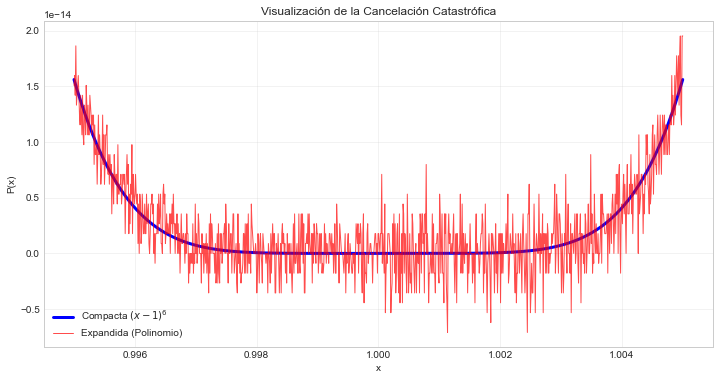

In [6]:
# Espacio para tu código

# 1. Definir dominio x
x = np.linspace(0.995, 1.005, 1000)

# 2. Evaluar forma compacta (Estable)
y_compacta = (x - 1)**6

# 3. Evaluar forma expandida (Inestable)
# Tip: Escribe la ecuación completa aquí
y_expandida = x**6 - 6*x**5 + 15*x**4 - 20*x**3 + 15*x**2 - 6*x + 1

# 4. Graficar
plt.figure(figsize=(12, 6))
plt.plot(x, y_compacta, label='Compacta $(x-1)^6$', linewidth=3, color='blue')
plt.plot(x, y_expandida, label='Expandida (Polinomio)', linewidth=1, color='red', alpha=0.7)

plt.title('Visualización de la Cancelación Catastrófica')
plt.xlabel('x')
plt.ylabel('P(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Thomas Fuhrer & Manuel A. Sánchez </strong><br>
        Profesores, <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT2605 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>